<a href="https://colab.research.google.com/github/ecpovedam/machinelearning/blob/main/Actividad_2_ML_II_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

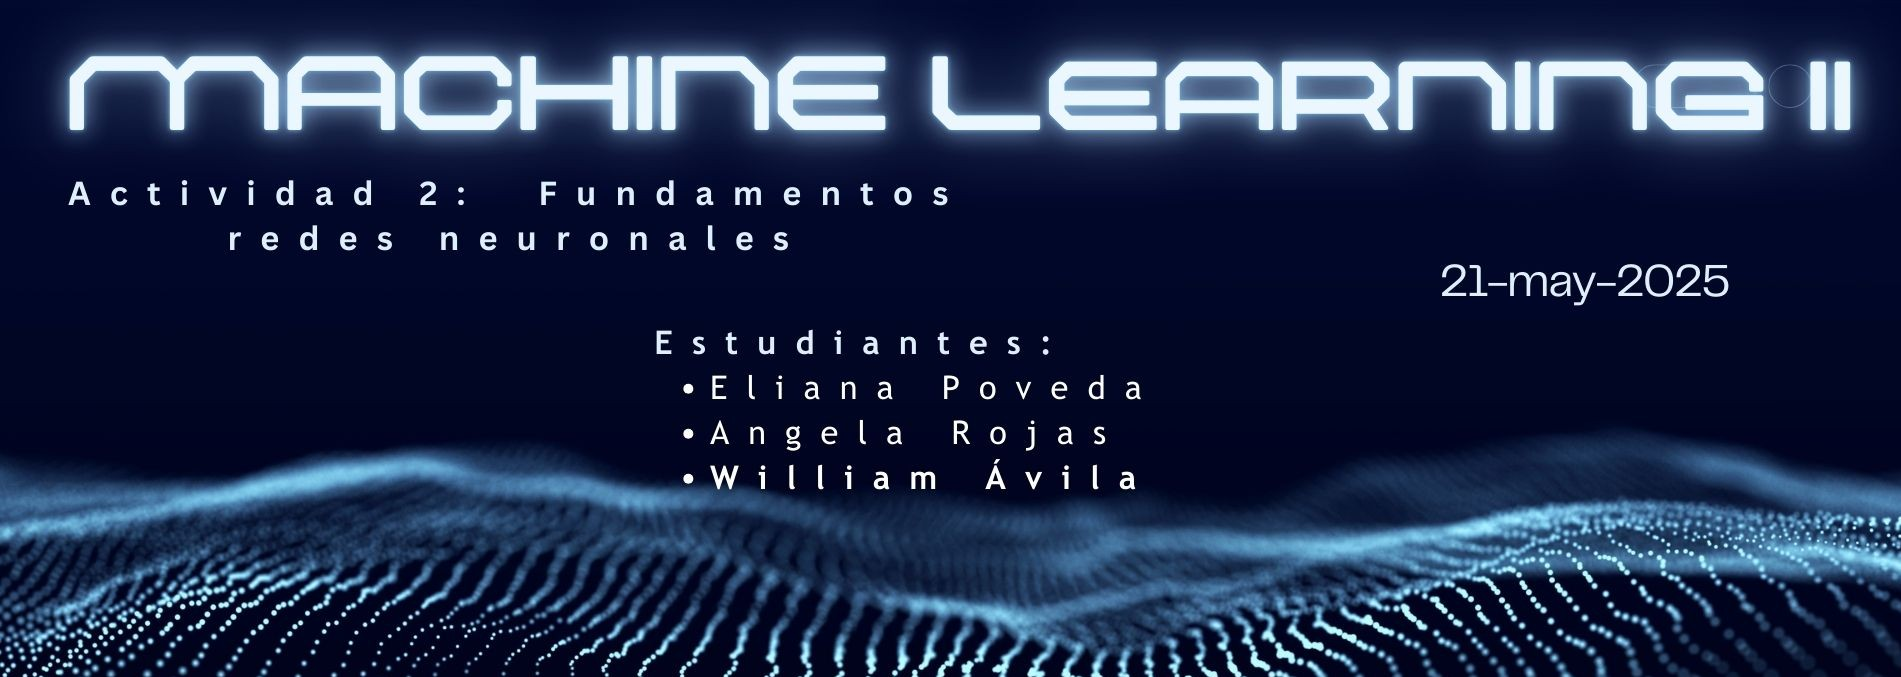

In [4]:
from IPython.display import Image, display
display(Image(filename="/encabezado_ml.jpg"))




**¿Qué es una red neuronal artificial?**

Una red neuronal es un programa o modelo de aprendizaje automático que toma decisiones de manera similar al cerebro humano, mediante el uso de procesos que imitan la forma en que las neuronas biológicas trabajan juntas para reconocer patrones, resolver tareas complejas y llegar a conclusiones.

Las redes neuronales a veces se denominan redes neuronales artificiales (ANN) y son un subconjunto del aprendizaje automático y están en el corazón de los modelos de aprendizaje profundo .

*   Neuronas: unidades básicas que reciben entradas (función), las procesan y generan una salida.

*   Pesos: son ponderaciones que ayudan a determinar la importancia de cada entrada o variable

*   Funciones de activación: Transforman la señal de entrada de una neurona en una señal de salida que pasa a la capa siguiente.


Capas:

*   Entrada: recibe los datos.
*   Ocultas: procesan la información.
*   Salida: genera la predicción final.


**Algoritmo de backpropagation y su importancia**

Las redes neuronales se basan en datos de entrenamiento para aprender y mejorar su precisión con el tiempo. Si la salida no coincide con lo esperado en el propagación hacia adelante, el algoritmo de backpropagation calcula el error y se propaga de vuelta a través de la red, ajustando los pesos y sesgos para minimizar el error.

Este proceso es fundamental ya que permite ajustar los pesos de manera eficaz para minimizar el error de predicción, optimizar el rendimiento del modelo y aprender representaciones complejas a partir de los datos.



**Funciones de activación**


*   Sigmoide: toma una entrada de valor real y la reduce a un valor entre 0 y 1.Útil en la capa de salida para tareas de clasificación binaria. Satura con valores extremos, con una pendiente extremadamente plana.

  f(x) = 1/(1 + e^-x)

*   ReLU: Umbraliza la entrada en cero, devolviendo 0 para valores negativos y la propia entrada para valores positivos.Muy usada en capas ocultas por su eficiencia computacional y capacidad de mitigar el problema del gradiente desaparecido.

  f(x) = max(0, x)

*   Tanh: Similar a sigmoide, pero con salida entre -1 y 1. Esto significa que puede tratar valores negativos con más eficacia que la función sigmoide, que tiene un intervalo de 0 a 1. Útil cuando se desea que la media de salida sea cero.

  f(x) = (e^x - e^ - x)/(e^x + e^ - x)











## **1. Carga dataset**

In [6]:
import pandas as pd
df = pd.read_csv('/creditcard.csv')
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,202103.000000,202103.000000,202103.000000,202103.000000,202103.000000,202103.000000,202103.000000,202103.000000,202103.000000,202103.000000,...,202103.000000,202103.000000,202103.000000,202103.000000,202103.000000,202103.000000,202103.000000,202103.000000,202102.000000,202102.000000
mean,71299.812897,-0.099626,0.002123,0.305508,0.072640,-0.106267,0.044187,-0.047521,0.015474,0.009143,...,-0.013941,-0.045129,-0.014986,0.003664,0.058581,0.005744,0.001485,0.001745,89.799687,0.001915
std,35036.881833,1.896911,1.626030,1.452783,1.399849,1.362698,1.312158,1.218968,1.208584,1.134439,...,0.737869,0.692919,0.614289,0.603941,0.493533,0.488262,0.395548,0.318411,248.942740,0.043717
min,0.000000,-56.407510,-72.715728,-33.680984,-5.683171,-42.147898,-26.160506,-43.557242,-73.216718,-13.434066,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.604551,-22.565679,-11.710896,0.000000,0.000000
25%,44528.000000,-0.960447,-0.583159,-0.359541,-0.795058,-0.780145,-0.712878,-0.575294,-0.182662,-0.662602,...,-0.226937,-0.537114,-0.168436,-0.342897,-0.243776,-0.331292,-0.067600,-0.042541,5.990000,0.000000
50%,67708.000000,-0.083145,0.079893,0.481227,0.073708,-0.163959,-0.220694,-0.007907,0.042076,-0.072723,...,-0.042064,-0.032761,-0.028248,0.051984,0.100751,-0.061202,0.005719,0.018203,23.000000,0.000000
75%,95691.000000,1.216586,0.783136,1.215357,0.881035,0.473303,0.442882,0.505039,0.337568,0.625674,...,0.152568,0.429097,0.116114,0.422327,0.383556,0.260538,0.089145,0.078110,79.420000,0.000000
max,134175.000000,2.454930,22.057729,9.382558,16.875344,34.801666,22.529298,36.677268,20.007208,15.594995,...,27.202839,10.503090,19.002942,4.022866,7.519589,3.517346,12.152401,33.847808,19656.530000,1.000000


# **2. Preprocesamiento**


**2.1. Valores nulos y tipos de datos**


---








In [7]:
#Mostrar la estructura del dataset, tipos de datos y nulos por cada variable.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 202103 entries, 0 to 202102
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    202103 non-null  float64
 1   V1      202103 non-null  float64
 2   V2      202103 non-null  float64
 3   V3      202103 non-null  float64
 4   V4      202103 non-null  float64
 5   V5      202103 non-null  float64
 6   V6      202103 non-null  float64
 7   V7      202103 non-null  float64
 8   V8      202103 non-null  float64
 9   V9      202103 non-null  float64
 10  V10     202103 non-null  float64
 11  V11     202103 non-null  float64
 12  V12     202103 non-null  float64
 13  V13     202103 non-null  float64
 14  V14     202103 non-null  float64
 15  V15     202103 non-null  float64
 16  V16     202103 non-null  float64
 17  V17     202103 non-null  float64
 18  V18     202103 non-null  float64
 19  V19     202103 non-null  float64
 20  V20     202103 non-null  float64
 21  V21     20

**2.2. Normalizar características numéricas**


---

In [8]:
# Importar librerías
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


In [18]:
# Estandarizar 'Amount' y 'Time' para que tengan media 0 y desviación estándar 1
# ya que no están transformadas como las variables V1 a V28, y los modelos de ML funcionan mejor con datos en escalas similares.
scaler = StandardScaler()
df[['Amount', 'Time']] = scaler.fit_transform(df[['Amount', 'Time']])

import numpy as np
df = df.dropna(subset=['Class'])
df['Class'] = df['Class'].astype(np.int64)
df['Class'].dtype



dtype('int64')

**2.3. Clases desbalanceadas**


---

La variable Class es la única categórica en el conjunto de datos y presenta un fuerte desbalance. La clase 0 (no fraude) representa el 99.8% de los casos, mientras que la clase 1 (fraude) corresponde únicamente al 0.19%. Esta desproporción puede afectar el rendimiento del modelo si no se maneja adecuadamente. Existen las siguientes posibilidades:

*   **Oversampling**: Aumentar la cantidad de muestras de la
clase minoritaria, por ejemplo, con técnicas como SMOTE.

*   **Undersampling**: Reducir la cantidad de muestras de la clase mayoritaria para equilibrar las clases.
*   **Ajuste de pesos**: Utilizar el parámetro class_weight en modelos como redes neuronales para penalizar más los errores en la clase minoritaria


*   **Uso de métricas adecuadas**: Evaluar el modelo con métricas como recall, F1-score o la matriz de confusión, en lugar de solo la precisión, que puede ser engañosa en contextos desbalanceados.



In [10]:
df['Class'].value_counts(normalize=True) * 100

,proportion
Class,
0.0,99.808513
1.0,0.191487


# **3. Modelo base con Keras**

**3.1. Crea un modelo simple con al menos 1 capa oculta (activación ReLU) y una capa de salida (sigmoide).**


---

In [26]:
#Paso 1: Separar X e y
X = df.drop(columns='Class')
y = df['Class']

# Paso 2: Dividir en conjunto de entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Importar componentes de Keras
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([ # Crear el modelo secuencial (capa por capa)
    Input(shape=(X_train.shape[1],)), # Definir la forma de entrada: cada muestra tiene 30 variables (features)
    Dense(16, activation='relu'),    # Capa oculta con 16 neuronas y activación ReLU
    Dense(1, activation='sigmoid')     # Capa de salida con 1 neurona y activación sigmoide para clasificación binaria (fraude o no)
])


**3.2. Compila el modelo con binary_crossentropy y métricas como accuracy.**


---

In [27]:
# Compilar el modelo: definir cómo se entrena
model.compile(
    optimizer='adam',                     # Optimizador eficiente y común
    loss='binary_crossentropy',           # Función de pérdida para clasificación binaria
    metrics=['accuracy']                  # Métrica para evaluar durante el entrenamiento
)

**3.3. Entrena el modelo y evalúa su rendimiento sobre un conjunto de prueba.**


---

In [29]:

# Entrenar el modelo con los datos de entrenamiento
history = model.fit(
    X_train, y_train,                     # Datos de entrenamiento
    epochs=10,                            # Número de veces que pasa por todos los datos
    batch_size=2048,                      # Número de muestras por paso de entrenamiento
    validation_split=0.2,                 # Usa el 20% de entrenamiento como validación
    verbose=1                             # Muestra barra de progreso
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.6838 - loss: 0.6010 - val_accuracy: 0.9518 - val_loss: 0.3263
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9739 - loss: 0.2799 - val_accuracy: 0.9959 - val_loss: 0.1760
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9964 - loss: 0.1561 - val_accuracy: 0.9983 - val_loss: 0.1077
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9984 - loss: 0.0967 - val_accuracy: 0.9988 - val_loss: 0.0710
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9987 - loss: 0.0651 - val_accuracy: 0.9989 - val_loss: 0.0495
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9989 - loss: 0.0463 - val_accuracy: 0.9990 - val_loss: 0.0362
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9988 - loss: 0.0350 - val_accuracy: 0.9991 - val_loss: 0.0276
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9990 - loss: 0.0266 - val_accuracy: 0.9991 - val_loss

En la primera época, la precisión (accuracy) del modelo fue relativamente baja (0.6838) y la pérdida en el conjunto de entrenamiento fue alta (0.6010), lo que indica que el modelo apenas comenzaba a aprender. Aun así, la precisión en el conjunto de validación ya alcanzaba 0.9518, con una pérdida de 0.32. Conforme avanzó el entrenamiento y el modelo aplicó retropropagación, todas las métricas mejoraron progresivamente. Al final de la décima época, la precisión llegó a 0.9992 y las pérdidas se redujeron notablemente tanto en entrenamiento como en validación, lo que muestra que el modelo logró aprender patrones de manera eficiente.

# **4. Visualización**

**4.1. Grafica la curva de pérdida y precisión para entrenamiento y validación.**


---

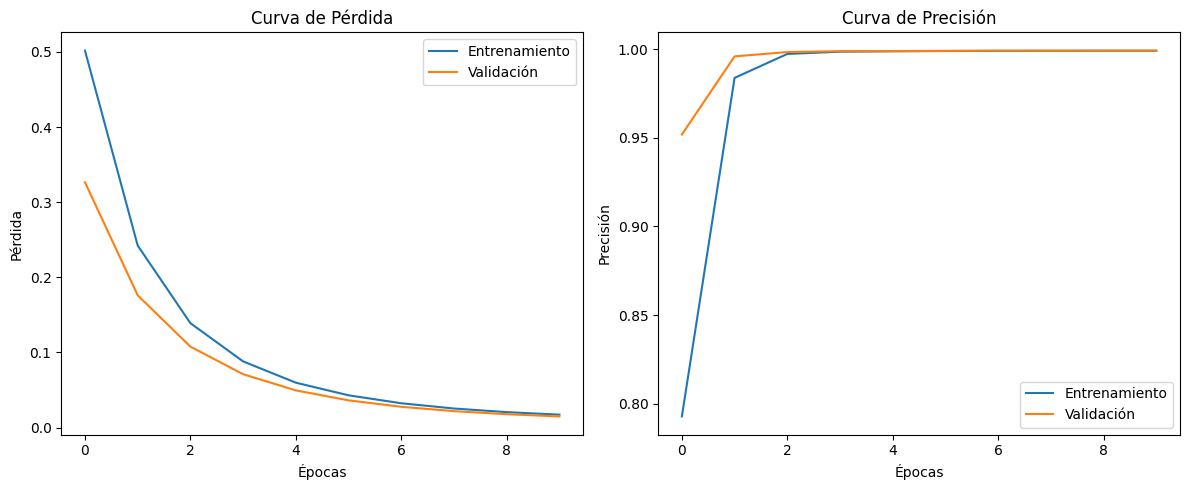

In [30]:
import matplotlib.pyplot as plt

# history: es el objeto que guarda todo el proceso de entrenamiento
# history.history: un diccionario con las métricas por época ('loss', 'val_loss', 'accuracy', 'val_accuracy

plt.figure(figsize=(12, 5))

# Curva de pérdida (loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Curva de Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

# Curva de precisión (accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Curva de Precisión')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

plt.tight_layout()
plt.show()

**4.2. Interpreta los resultados obtenidos.**


---

La pérdida disminuye de forma estable en entrenamiento y validación, sin señales de sobreajuste. Llama la atención que la validación arranca con menor pérdida, posiblemente por la forma en que se calcula. En precisión, el modelo mejora muy rápido: desde la segunda época ambas curvas se igualan y se mantienen altas, lo que muestra un buen aprendizaje desde el inicio.

# **5. Modelo con Droupout**

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Dense, Dropout

# Crear modelo con Dropout y nombre específico
model_dropout = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(16, activation='relu'),
    Dropout(0.3),  # Apaga el 30% de las neuronas durante el entrenamiento
    Dense(1, activation='sigmoid')
])

# Compilar el modelo
model_dropout.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Entrenar el modelo y guardar historial
history_dropout = model_dropout.fit(
    X_train, y_train,
    epochs=10,
    batch_size=2048,
    validation_split=0.2,
    verbose=1
)


Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.1452 - loss: 1.4469 - val_accuracy: 0.4053 - val_loss: 0.8767
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4919 - loss: 0.8052 - val_accuracy: 0.8256 - val_loss: 0.5101
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7629 - loss: 0.5035 - val_accuracy: 0.9639 - val_loss: 0.3259
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9007 - loss: 0.3498 - val_accuracy: 0.9931 - val_loss: 0.2223
Epoch 5/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9556 - loss: 0.2578 - val_accuracy: 0.9985 - val_loss: 0.1581
Epoch 6/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9769 - loss: 0.2025 - val_accuracy: 0.9993 - val_loss: 0.1161
Epoch 7/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9876 - loss: 0.1628 - val_accuracy: 0.9992 - val_loss: 0.0880
Epoch 8/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9934 - loss: 0.1381 - val_accuracy: 0.9992 - val_loss:

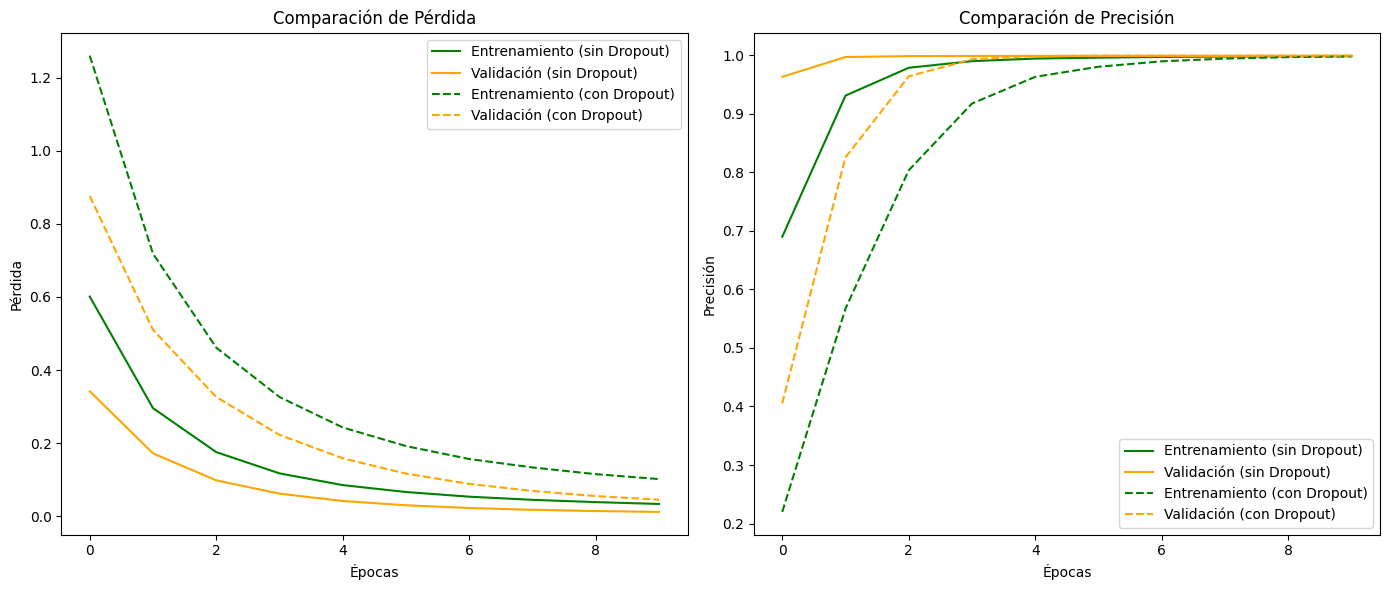

In [35]:
plt.figure(figsize=(14, 6))

# --- PÉRDIDA ---
plt.subplot(1, 2, 1)

# Modelo original
plt.plot(history.history['loss'], label='Entrenamiento (sin Dropout)', color='green', linestyle='-')
plt.plot(history.history['val_loss'], label='Validación (sin Dropout)', color='orange', linestyle='-')

# Modelo con Dropout
plt.plot(history_dropout.history['loss'], label='Entrenamiento (con Dropout)', color='green', linestyle='--')
plt.plot(history_dropout.history['val_loss'], label='Validación (con Dropout)', color='orange', linestyle='--')

plt.title('Comparación de Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

# --- PRECISIÓN ---
plt.subplot(1, 2, 2)

# Modelo original
plt.plot(history.history['accuracy'], label='Entrenamiento (sin Dropout)', color='green', linestyle='-')
plt.plot(history.history['val_accuracy'], label='Validación (sin Dropout)', color='orange', linestyle='-')

# Modelo con Dropout
plt.plot(history_dropout.history['accuracy'], label='Entrenamiento (con Dropout)', color='green', linestyle='--')
plt.plot(history_dropout.history['val_accuracy'], label='Validación (con Dropout)', color='orange', linestyle='--')

plt.title('Comparación de Precisión')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

plt.tight_layout()
plt.show()




Al principio pensamos que al usar Dropout el modelo mejoraría su rendimiento, ya que asociábamos una mayor precisión y una curva de pérdida más baja con mejores resultados. Sin embargo, al investigar más a fondo, entendimos que Dropout introduce aleatoriamente ruido durante el entrenamiento para evitar que el modelo dependa demasiado de ciertas neuronas. Esto, aunque puede provocar que la precisión disminuya un poco y la pérdida aumente, en realidad ayuda a que el modelo generalice mejor y no se sobreentrene con los datos.

Aunque el primer modelo muestra métricas más altas, el modelo con Dropout presenta un aprendizaje más equilibrado y con menor riesgo de sobreajuste, lo que podría hacerlo más confiable al enfrentarse a nuevos datos.

Para confirmar esta hipótesis con mayor certeza, consideramos necesario evaluar ambos modelos con métricas más sensibles al desbalance de clases, como el recall, el F1-score y la matriz de confusión, enfocándonos especialmente en el comportamiento frente a la detección de fraudes.